<a href="https://colab.research.google.com/github/pedroedu02/Chalenge1_PosTech/blob/main/Chalenge1_PosTech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

orders = pd.read_csv('/content/olist_orders_dataset.csv')
customers = pd.read_csv('/content/olist_customers_dataset.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
sellers = pd.read_csv('/content/olist_sellers_dataset.csv')
geolocation = pd.read_csv('/content/olist_geolocation_dataset.csv')


#FAZENDO ANALISE GERAL DOS DATASETS PARA VER OS PONTOS A SE FALAR.
# Visão geral pedidos
orders.head()
orders.info()

# Datas (pra ver o período dos pedidos)
print(orders['order_purchase_timestamp'].min())
print(orders['order_purchase_timestamp'].max())

# Status dos pedidos
print(orders['order_status'].value_counts())

# Avaliações dos clientes
reviews.head()
print(reviews['review_score'].value_counts())

# Pagamentos realizados
payments.head()
print(payments['payment_type'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
2016-09-04 21:15:19
2018-10-17 17:30:18
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
review_score
5 

**LEITURA DOS DADOS**

- TAMANHO DOS DATASETS:
99 mil pedidos → base robusta

- PERIDODO DE PEDIDOS:
2016 → 2018 (evolução e sazonalidade)

- STATUS:
97% entregues (delivered)
poucos cancelados / problemas em qualidade da entrega (tempo e experiência)

- AVALIAÇÕES:
5 estrelas → MUITO dominante
1 estrela  → volume relevante (~11k)
clientes muito satisfeitos ou muito insatisfeitos

- PAGAMENTOS:
cartão domina (77%)
boleto relevante (20%)


***STORYTELLING: INTRODUÇÃO***

O crescimento do e-commerce mostra desafios relacionados a experiência do cliente, especialmente quando se observa a entrega e a qualidade do serviço.

A partir de uma base de aproximadamente 99 mil pedidos realizados em um périodo entre 2016 e 2018, é possível observar pedidos entregues com sucesso, representando cerca de 97% do total.

Apesar disso, a análise das avaliações revela um comportamento adverso onde enquanto a maioria dos clientes atribui nota máxima, há um volume significativo de avaliações extremamente baixas, indicando possíveis falhas na experiência.

Além disso, o uso predominante de cartão de crédito e a presença relevante de boletos mostram diferentes perfis de consumo, que podem influenciar a jornada do cliente.

Diante desse contexto, surge a seguinte questão de negócio:

Quais fatores impactam a satisfação do cliente no e-commerce, com foco no tempo de entrega e na experiência logística?

Para responder a essa pergunta, foram definidas hipóteses relacionadas ao tempo de entrega, atrasos logísticos e características financeiras dos pedidos, buscando identificar quais variáveis mais influenciam a percepção do cliente.


***LIMPEZA, PREPARAÇÃO E ANÁLISE DOS DADOS E OUTLIERS***

Inicialmente, foi realizada a remoção de registros duplicados em todas as tabelas, garantindo a integridade dos dados.

Em seguida, as colunas de data foram convertidas para o formato adequado, permitindo a realização de cálculos relacionados ao tempo de entrega.

Para garantir a consistência da análise, foram considerados apenas pedidos com status “delivered”, por representarem a experiência completa do cliente.

Registros com informações essenciais ausentes, como a data de entrega e a avaliação do cliente, foram removidos, assegurando maior confiabilidade nos resultados e evitando distorções nas análises.

Posteriormente, foram criadas variáveis derivadas, como o tempo de entrega e o atraso em relação à previsão, fundamentais para a análise da experiência logística.

Após essa etapa, foi realizada uma análise estatística do tempo de entrega, incluindo o cálculo de média (11,87 dias), mediana (10 dias) e desvio padrão (8,40 dias), permitindo compreender o comportamento geral da distribuição.

A análise revelou uma leve assimetria à direita, evidenciada pela diferença entre média e mediana, indicando a presença de valores extremos.

A distribuição dos dados foi explorada por meio de histogramas e boxplots, que evidenciaram a existência de outliers, principalmente relacionados a entregas com tempos significativamente superiores ao padrão observado.

Valores inconsistentes, como tempos de entrega negativos, foram removidos por não representarem cenários possíveis. No entanto, os demais outliers foram mantidos na análise, por serem considerados reflexos de variações reais do processo logístico, como atrasos operacionais ou dificuldades de entrega.

Por fim, os dados foram consolidados em um único dataset analítico, por meio da integração das tabelas de pedidos, pagamentos, avaliações e itens, permitindo uma visão integrada das variáveis de negócio para as análises posteriores.

Média: 12.09
Mediana: 10.00
Desvio padrão: 9.55


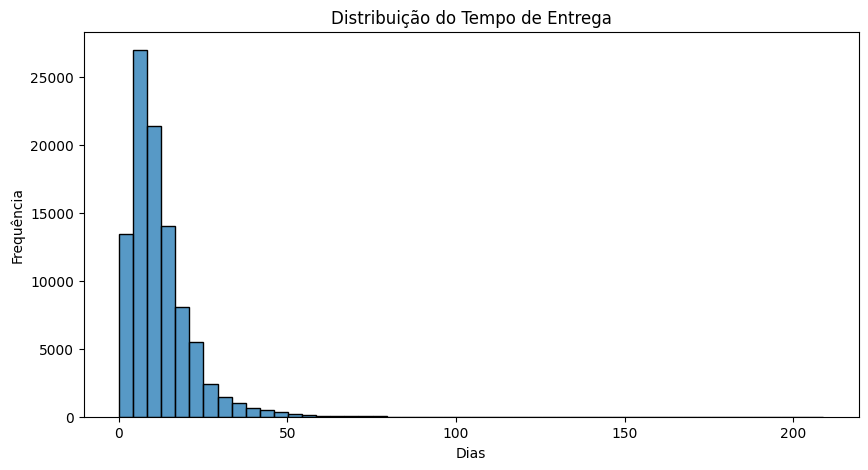

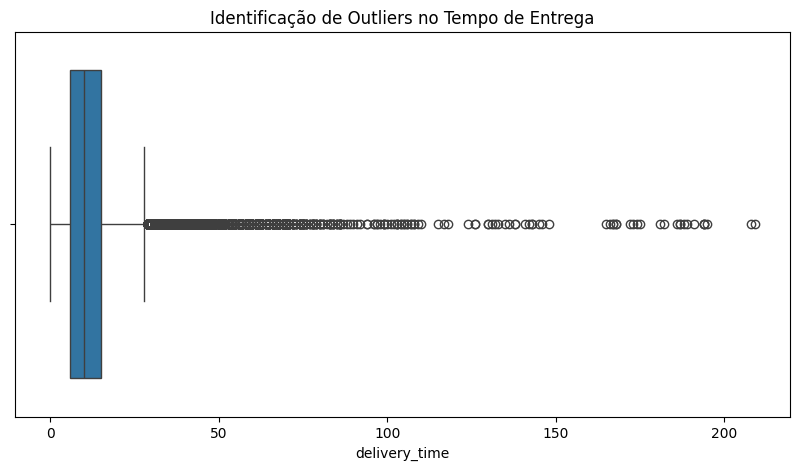

Quantidade de outliers: 5022
Limite superior: 28.5
Dimensão final do dataset: (100626, 14)
<class 'pandas.core.frame.DataFrame'>
Index: 100626 entries, 0 to 100640
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       100626 non-null  object        
 1   customer_id                    100626 non-null  object        
 2   order_status                   100626 non-null  object        
 3   order_purchase_timestamp       100626 non-null  datetime64[ns]
 4   order_approved_at              100626 non-null  datetime64[ns]
 5   order_delivered_carrier_date   100626 non-null  datetime64[ns]
 6   order_delivered_customer_date  100626 non-null  datetime64[ns]
 7   order_estimated_delivery_date  100626 non-null  datetime64[ns]
 8   delivery_time                  100626 non-null  int64         
 9   delay                          100626 non-null  in

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delay,review_score,payment_value,price,freight_value
count,100626,100626,100626,100626,100626,100626.00000,100626.000000,100626.000000,100626.000000,100626.000000,100626.000000
mean,2017-12-31 09:55:01.736797696,2017-12-31 20:05:47.486921728,2018-01-03 15:16:52.891538944,2018-01-12 22:43:30.223600384,2018-01-24 04:23:34.155387136,12.06867,-11.933635,4.153996,152.648375,136.684733,22.795566
min,2016-10-03 09:44:50,2016-10-04 09:43:32,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-27 00:00:00,0.00000,-147.000000,1.000000,0.000000,0.850000,0.000000
25%,2017-09-11 23:26:15.249999872,2017-09-12 12:05:10.500000,2017-09-14 17:27:33.750000128,2017-09-22 12:47:01.500000,2017-10-03 00:00:00,6.00000,-17.000000,4.000000,56.780000,45.900000,13.860000
50%,2018-01-18 20:03:30,2018-01-19 08:15:41,2018-01-23 16:38:59,2018-02-01 11:02:32.500000,2018-02-15 00:00:00,10.00000,-12.000000,5.000000,99.900000,85.900000,17.190000
75%,2018-05-04 14:55:37,2018-05-04 22:09:08.750000128,2018-05-08 08:27:00,2018-05-15 16:23:01.500000,2018-05-25 00:00:00,15.00000,-7.000000,5.000000,171.000000,149.900000,24.000000
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,208.00000,188.000000,5.000000,13664.080000,13440.000000,1794.960000
std,NaN,NaN,NaN,NaN,NaN,9.46675,10.114884,1.286102,212.849886,207.805023,21.441179


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# LIMPEZA, PREPARAÇÃO E ANÁLISE DOS DADOS e OUTLIERS

# LIMPEZA DE DUPLICADOS
# Garantir que não existem registros repetidos

orders = orders.drop_duplicates()
customers = customers.drop_duplicates()
order_items = order_items.drop_duplicates()
payments = payments.drop_duplicates()
reviews = reviews.drop_duplicates()
products = products.drop_duplicates()

# CONVERSÃO DE DATAS
# Converter colunas para datetime para permitir cálculos

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# FILTRAR PEDIDOS RELEVANTES
# Foco apenas em pedidos entregues com status entregue para ter avaliação de cliente.

orders = orders[orders['order_status'] == 'delivered'].copy()

# LIMPEZA DE VALORES NULOS
# Orders → necessário para calcular entrega
orders = orders.dropna(subset=['order_delivered_customer_date'])

# Reviews → essencial para análise de satisfação
reviews = reviews.dropna(subset=['review_score'])

# Payments → necessário para análise financeira
payments = payments.dropna(subset=['payment_value'])

# Order items → necessário para cálculo de valor e frete
order_items = order_items.dropna(subset=['price', 'freight_value'])

# Products → manter, mas preencher categoria desconhecida
products['product_category_name'] = products['product_category_name'].fillna('unknown')


# Criar variáveis de negócio
orders['delivery_time'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

orders['delay'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days


# ANÁLISE ESTATÍSTICA E OUTLIERS
#  Remover valores impossíveis - Delivery time negativo não faz sentido

orders = orders[orders['delivery_time'] >= 0]

# Estatísticas descritivas

media = orders['delivery_time'].mean()
mediana = orders['delivery_time'].median()
desvio = orders['delivery_time'].std()

print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desvio padrão: {desvio:.2f}")

# Distribuição dos dados

plt.figure(figsize=(10,5))
sns.histplot(orders['delivery_time'], bins=50)
plt.title('Distribuição do Tempo de Entrega')
plt.xlabel('Dias')
plt.ylabel('Frequência')
plt.show()

# Identificação de outliers (Boxplot)
plt.figure(figsize=(10,5))
sns.boxplot(x=orders['delivery_time'])
plt.title('Identificação de Outliers no Tempo de Entrega')
plt.show()

# Método IQR

Q1 = orders['delivery_time'].quantile(0.25)
Q3 = orders['delivery_time'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = orders[
    (orders['delivery_time'] < limite_inferior) |
    (orders['delivery_time'] > limite_superior)
]

print("Quantidade de outliers:", outliers.shape[0])
print("Limite superior:", limite_superior)

# ajuste de valores por pedido

order_items_agg = order_items.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()

# CRIAÇÃO DO DATASET FINAL
# Unindo todas as tabelas relevantes e mergeando todas pra fazer nossa modelagem

df = orders.merge(reviews[['order_id','review_score']], on='order_id', how='inner') \
           .merge(payments[['order_id','payment_value']], on='order_id', how='inner') \
           .merge(order_items_agg, on='order_id', how='inner')

# LIMPEZA FINAL

df = df.dropna()

# VALIDAÇÃO FINAL

print("Dimensão final do dataset:", df.shape)
df.info()
df.describe()

/tmp/ipykernel_19019/551722959.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='order_id', data=kpi_orders, ax=ax1, palette='viridis')
/tmp/ipykernel_19019/551722959.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='delivery_time', data=kpi_delivery, ax=ax2, palette='viridis')
/tmp/ipykernel_19019/551722959.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='review_score', data=kpi_review, ax=ax4, palette='viridis')
/tmp/ipykernel_19019/551722959.py:98: FutureWarning: 

Passing `palette` without

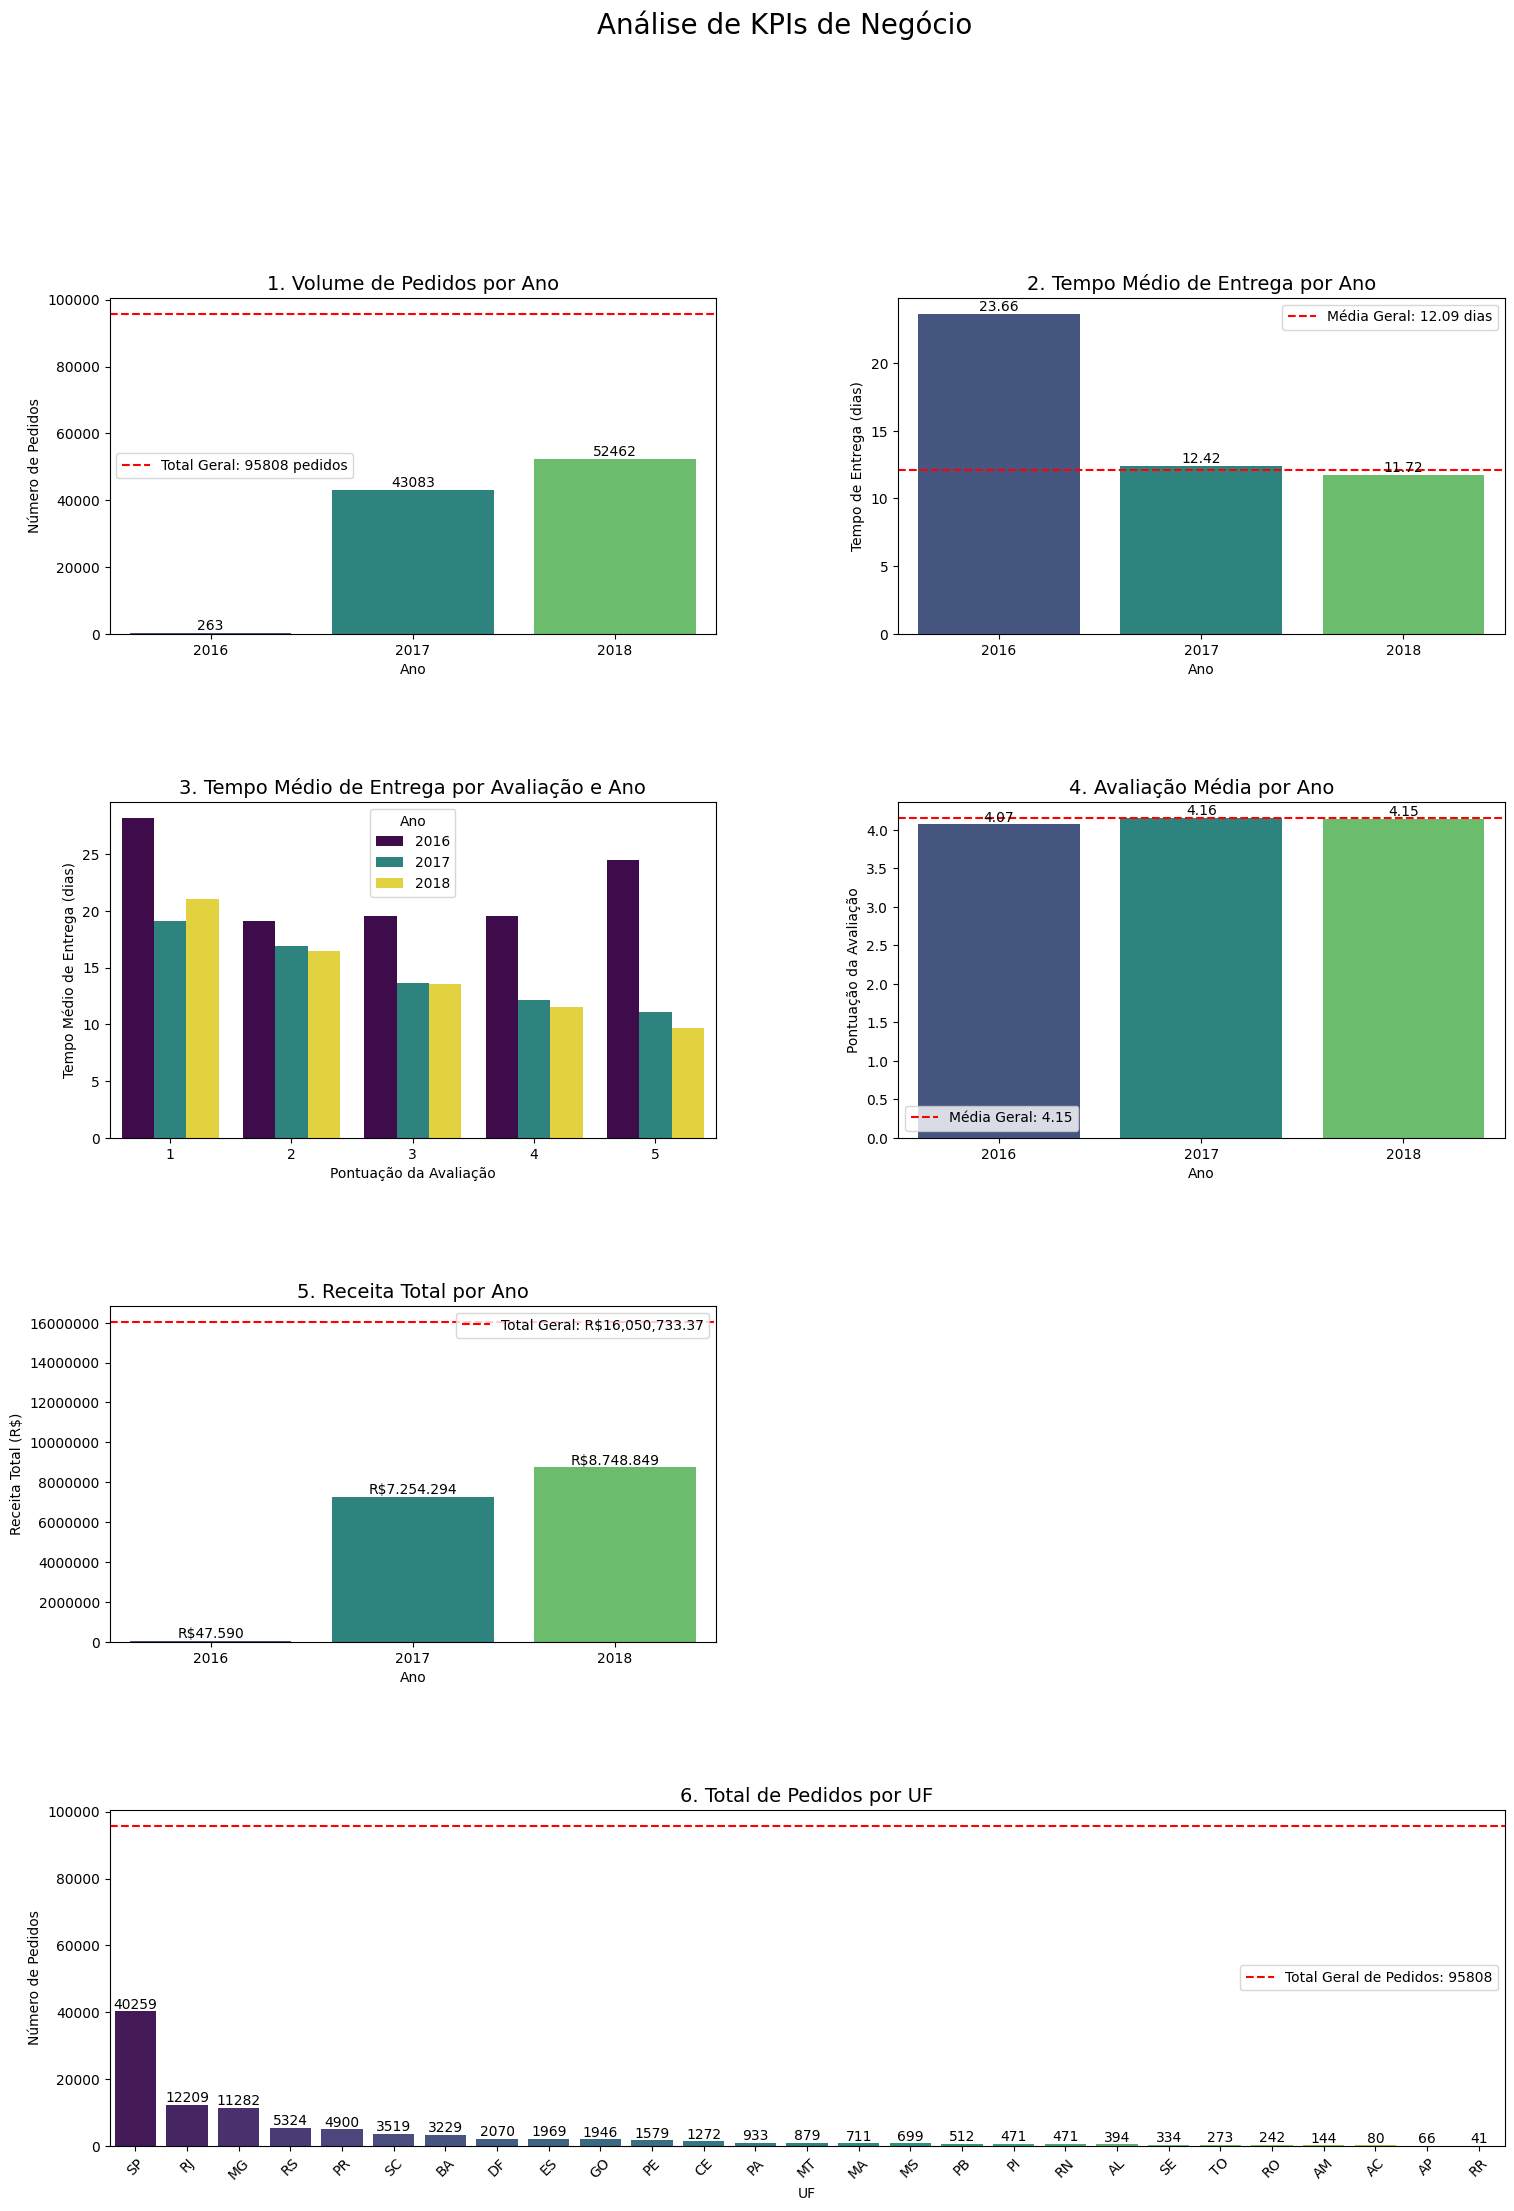


--- KPIs Anuais ---

1. Pedidos Anuais:
    year  order_id
0  2016       263
1  2017     43083
2  2018     52462
Total Geral de Pedidos: 95808

2. Tempo Médio de Entrega Anual:
    year  delivery_time
0  2016      23.657143
1  2017      12.423479
2  2018      11.719998
Média Geral de Tempo de Entrega: 12.09 dias

3. Tempo Médio de Entrega por Avaliação e Ano:
     year  review_score  delivery_time
0   2016             1      28.200000
1   2016             2      19.142857
2   2016             3      19.583333
3   2016             4      19.537037
4   2016             5      24.497653
5   2017             1      19.066436
6   2017             2      16.930259
7   2017             3      13.619849
8   2017             4      12.128545
9   2017             5      11.040038
10  2018             1      21.074596
11  2018             2      16.468131
12  2018             3      13.518174
13  2018             4      11.552568
14  2018             5       9.689683

4. Avaliação Média Anual:
 

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec


# Garante que df_kpi seja criado com as colunas necessárias
df_kpi = df.copy()
df_kpi['year'] = df_kpi['order_purchase_timestamp'].dt.year
df_kpi['is_delayed'] = df_kpi['delay'] > 0
df_kpi['bad_review'] = df_kpi['review_score'] <= 2
# Junta o tipo de pagamento (payment_type) em df_kpi
df_kpi = df_kpi.merge(payments[['order_id', 'payment_type']], on='order_id', how='left')

# CÁLCULO DOS KPIS ANUAIS E TOTAIS

kpi_orders = df_kpi.groupby('year')['order_id'].nunique().reset_index()
kpi_orders_total = df_kpi['order_id'].nunique()

kpi_delivery = df_kpi.groupby('year')['delivery_time'].mean().reset_index()
kpi_delivery_total = df_kpi['delivery_time'].mean()

kpi_review = df_kpi.groupby('year')['review_score'].mean().reset_index()
kpi_review_total = df_kpi['review_score'].mean()

kpi_revenue = df_kpi.groupby('year')['payment_value'].sum().reset_index()
kpi_revenue_total = df_kpi['payment_value'].sum()

# --- KPIs---

# KPI: Tempo de Entrega x Avaliação (por ano)
kpi_delivery_review_year = df_kpi.groupby(['year', 'review_score'])['delivery_time'].mean().reset_index()

# KPI: Avaliações x Formas de Pagamento (total geral) - NÃO USADO PARA PLOTAGEM CONFORME SOLICITADO PELO USUÁRIO
kpi_review_payment = df_kpi.groupby(['payment_type', 'review_score']).size().unstack(fill_value=0)

# --- Calcula totais para pontuações de avaliação para o KPI 7 ---
review_score_totals = kpi_review_payment.sum(axis=0) # Soma por tipo de pagamento para cada pontuação de avaliação

# KPI 6: Pedidos Totais por UF (Cálculos, anteriormente em uma célula separada)
# Junta df com clientes para obter a UF
df_uf = df.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

kpi_orders_by_uf = df_uf.groupby('customer_state')['order_id'].nunique().reset_index()
kpi_orders_by_uf = kpi_orders_by_uf.sort_values(by='order_id', ascending=False)



# plots DOS kpis

#Ajuste dos gráficos
fig = plt.figure(figsize=(18, 24)) # Aumentou ligeiramente a altura e largura para melhor distribuição
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.3)
fig.suptitle('Análise de KPIs de Negócio', fontsize=20, y=1.0)

# KPI 1 — Volume de pedidos
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(x='year', y='order_id', data=kpi_orders, ax=ax1, palette='viridis')
ax1.axhline(kpi_orders_total, color='red', linestyle='--', label=f'Total Geral: {int(kpi_orders_total)} pedidos')
ax1.set_title('1. Volume de Pedidos por Ano', fontsize=14)
ax1.set_xlabel('Ano')
ax1.set_ylabel('Número de Pedidos')
ax1.legend()
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d') # Adiciona rótulos

# KPI 2 — Tempo médio de entrega
ax2 = fig.add_subplot(gs[0, 1])
sns.barplot(x='year', y='delivery_time', data=kpi_delivery, ax=ax2, palette='viridis')
ax2.axhline(kpi_delivery_total, color='red', linestyle='--', label=f'Média Geral: {kpi_delivery_total:.2f} dias')
ax2.set_title('2. Tempo Médio de Entrega por Ano', fontsize=14)
ax2.set_xlabel('Ano')
ax2.set_ylabel('Tempo de Entrega (dias)')
ax2.legend()
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f') # Adiciona rótulos

# KPI 3 — Tempo de Entrega x Avaliação (por ano)
ax3 = fig.add_subplot(gs[1, 0])
sns.barplot(x='review_score', y='delivery_time', hue='year', data=kpi_delivery_review_year, ax=ax3, palette='viridis')
ax3.set_title('3. Tempo Médio de Entrega por Avaliação e Ano', fontsize=14)
ax3.set_xlabel('Pontuação da Avaliação')
ax3.set_ylabel('Tempo Médio de Entrega (dias)')
ax3.legend(title='Ano')

# KPI 4 — Avaliação média
ax4 = fig.add_subplot(gs[1, 1])
sns.barplot(x='year', y='review_score', data=kpi_review, ax=ax4, palette='viridis')
ax4.axhline(kpi_review_total, color='red', linestyle='--', label=f'Média Geral: {kpi_review_total:.2f}')
ax4.set_title('4. Avaliação Média por Ano', fontsize=14)
ax4.set_xlabel('Ano')
ax4.set_ylabel('Pontuação da Avaliação')
ax4.legend()
for container in ax4.containers:
    ax4.bar_label(container, fmt='%.2f') # Adiciona rótulos

# KPI 5 — Receita total
ax5 = fig.add_subplot(gs[2, 0]) # Agora o KPI 5 está na linha 2, coluna 0
sns.barplot(x='year', y='payment_value', data=kpi_revenue, ax=ax5, palette='viridis')
ax5.axhline(kpi_revenue_total, color='red', linestyle='--', label=f'Total Geral: R${kpi_revenue_total:,.2f}')
ax5.set_title('5. Receita Total por Ano', fontsize=14)
ax5.set_xlabel('Ano')
ax5.set_ylabel('Receita Total (R$)')
ax5.ticklabel_format(style='plain', axis='y') # Evita notação científica para números grandes
ax5.legend()
for container in ax5.containers:
    labels = [f"R${val:,.0f}".replace(",", "TEMP").replace(".", ",").replace("TEMP", ".") for val in container.datavalues]
    ax5.bar_label(container, labels=labels)

# KPI 6: Pedidos Totais por UF (Plotagem na grade, agora abrangendo a linha inferior inteira)
ax6 = fig.add_subplot(gs[3, :]) # O KPI 6 abrange ambas as colunas na óltima linha
sns.barplot(x='customer_state', y='order_id', data=kpi_orders_by_uf, ax=ax6, palette='viridis')
ax6.axhline(kpi_orders_total, color='red', linestyle='--', label=f'Total Geral de Pedidos: {int(kpi_orders_total)}') # Adiciona o total similar ao KPI 1
ax6.set_title('6. Total de Pedidos por UF', fontsize=14)
ax6.set_xlabel('UF')
ax6.set_ylabel('Número de Pedidos')
ax6.tick_params(axis='x', rotation=45)
ax6.legend() # Adiciona legenda para a linha horizontal
for container in ax6.containers:
    ax6.bar_label(container, fmt='%d') # Adiciona rótulos

fig.delaxes(fig.add_subplot(gs[2,1])) # Exclui o subplot vazio em gs[2,1] para evitar que ele apareça

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para evitar sobreposição de títulos
plt.show()

# informações gerais dos KPIS

print("\n--- KPIs Anuais ---")
print("\n1. Pedidos Anuais:\n", kpi_orders)
print(f"Total Geral de Pedidos: {int(kpi_orders_total)}")

print("\n2. Tempo Médio de Entrega Anual:\n", kpi_delivery)
print(f"Média Geral de Tempo de Entrega: {kpi_delivery_total:.2f} dias")

print("\n3. Tempo Médio de Entrega por Avaliação e Ano:\n", kpi_delivery_review_year)

print("\n4. Avaliação Média Anual:\n", kpi_review)
print(f"Média Geral de Avaliação: {kpi_review_total:.2f}")

print("\n5. Receita Total Anual:\n", kpi_revenue)
print(f"Total Geral de Receita: R${kpi_revenue_total:,.2f}")

print("\n6. Total de Pedidos por UF:\n", kpi_orders_by_uf)


***CONCLUSÃO GERAL***

A análise dos dados revelou um cenário de crescimento consistente do e-commerce ao longo do período analisado (2016–2018), evidenciado pelo aumento significativo no volume de pedidos e na receita total.

No entanto, esse crescimento trouxe impactos operacionais relevantes, especialmente no início do período, onde o tempo médio de entrega era significativamente mais elevado. Ao longo dos anos, observa-se uma melhora importante na eficiência logística, com redução expressiva no tempo de entrega.

A análise da relação entre tempo de entrega e avaliação indica que pedidos com maior tempo tendem a receber notas mais baixas, confirmando que a experiência logística é um fator determinante na satisfação do cliente.

Apesar das melhorias operacionais, a avaliação média permaneceu relativamente estável ao longo do tempo, sugerindo que outros fatores além da logística também influenciam a percepção do cliente.

Além disso, a concentração de pedidos em determinadas regiões (como São Paulo) indica possíveis desequilíbrios logísticos e oportunidades de otimização geográfica.

De forma geral, os resultados mostram que, embora o crescimento do negócio seja positivo, a eficiência operacional e a experiência do cliente precisam ser continuamente monitoradas para sustentar esse crescimento de forma saudável.


***Pontos Positivos:***

> Forte crescimento de pedidos (escala do negócio)

> Aumento significativo da receita

> Redução do tempo médio de entrega ao longo dos anos

> Estabilidade na avaliação média (4.1)


***Pontos de Atenção:***

> Presença de atrasos e outliers relevantes

> Relação clara entre atraso e baixa avaliação

> Alta concentração geográfica (risco logístico)


Embora o crescimento do negócio tenha sido acompanhado por avanços logísticos, a satisfação do cliente continua diretamente impactada pelo tempo de entrega. Nesse contexto, o foco estratégico deve estar na criação de iniciativas que aumentem a velocidade e a eficiência das entregas, garantindo uma melhor experiência ao cliente e sustentando a escalabilidade do negócio
